### Prepare wind fields for wind ninja, at least, get it started to see what to do 

Notebook contents 
* Creating a few small wind field time series to test Wind Ninja with
* Then, loading some test data and going from there...

created by Cassie Lumbrazo\
last updated: July 2025\
run location: UAS linux\
python environment: **rasterio**

In [35]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

In [36]:
from scipy import ndimage

from rasterio.fill import fillnodata

from osgeo import gdal # installed gdal into `rasterio` conda env
import shutil
from pyproj import Transformer

In [37]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

# Wind Ninja Input Data 
* an elevation data file for the modeling area 
* a domain-averaged input wind speed and direction, and
* a specification of the dominant vegetation in the area 

The DEM prep is completed in `6a_load_clip_arctic_dem.ipynb` and `6b_fill_resample_dem_gdal.ipynb`

## Now, the Wind Data

We just want to save a week or a month of a wind speed and wind direction for the clipped area defined above to test...

In [38]:
filepath = "/hdd/snow_hydrology/hrrrak/netcdf/"
filename = "hrrrak_merged_grib_f567_WY2025_test1.nc"

# load data
ds_hrrr = xr.open_dataset(filepath + filename)
# ds_hrrr = ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # EPSG:32608 is the UTM zone 8N, which is the zone for the Powderpatch area
ds_hrrr = ds_hrrr.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon
ds_hrrr

<xarray.Dataset> Size: 413MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables: (12/52)
    pt                       (time, y, x) float32 8MB ...
    temp                     (time, y, x) float32 8MB ...
    d2m                      (time, y, x) float32 8MB ...
    sh2                      (time, y, x) float32 8MB ...
    rh                       (time, y, x) float32 8MB ...
    u10                      (time, y, x) float32 8MB ...
    ...                       ...
    lai                      (time, y, x) float32 8MB ...
    vgtyp                    (time, y, x) float32 8MB ...
    cloud_total              (time, y, x) float32 8MB ...
    cloud_high               (time, y, x) float32 8MB ...
    cloud_low                (time, y, x) float32 8MB ...
    wind                     (time, y, x) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

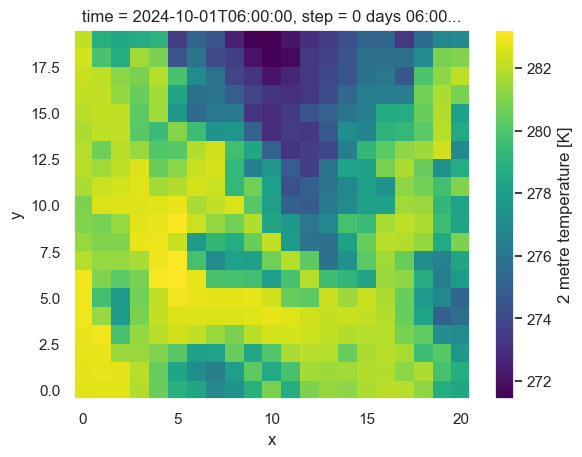

In [39]:
ds_hrrr["temp"][1].plot()

<xarray.Dataset> Size: 32MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables:
    u10                      (time, y, x) float32 8MB -4.269 -2.144 ... 0.7717
    v10                      (time, y, x) float32 8MB -3.529 -3.779 ... 1.997
    wind_speed               (time, y, x) float32 8MB 5.539 4.345 ... 2.141
    wind_direction           (time, y, x) float32 8MB 230.4 209.6 ... 21.13
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

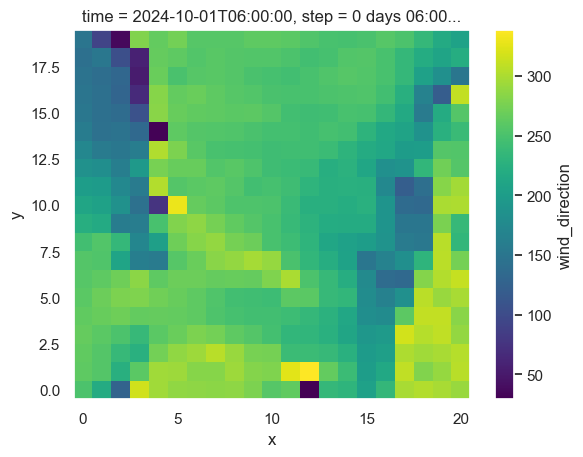

In [40]:
# Now we know we have the wind speed, calculated from u and v components, in the ds_hrrr dataset.
# And we want to calculate the wind direction from the u and v components.
# The wind direction is calculated as the arctangent of the ratio of the u and v
# components, using the numpy arctan2 function.
# The wind direction is given in degrees, with 0 degrees being north, 90 degrees
# being east, 180 degrees being south, and 270 degrees being west.

# u10 = west-east wind component (m/s)
# v10 = south-north wind component (m/s)

# the general equation being, 
# wind_dir = (180 / np.pi) * np.arctan2(-u10, -v10)
# wind_dir = (wind_dir + 360) % 360  # Convert to compass bearing

# calculate wind speed from u and v components
ds_hrrr['wind_speed'] = np.sqrt(ds_hrrr['u10']**2 + ds_hrrr['v10']**2)

# implemented, 
ds_hrrr["wind_direction"] = (180 * np.arctan2(ds_hrrr["u10"], ds_hrrr["v10"]) / np.pi)
ds_hrrr["wind_direction"] = (ds_hrrr["wind_direction"]+360) % 360 # convert to compass bearing 
ds_hrrr["wind_direction"][1].plot()

# Now we want to save a very simple version of a dataset, with only the wind speed and direction, for use in WindNinja.
# ds_hrrr_wind = ds_hrrr[["wind_speed", "wind_direction"]].copy()
ds_hrrr_wind = ds_hrrr[["u10", "v10", "wind_speed", "wind_direction"]].copy()
ds_hrrr_wind

A result of 
* 0° means wind is from the north
* 90° = from the east
* 180° = from the south
* 270° = from the west

`ds.x` and `ds.y` are 2D arrays, and `rioxarray` expects `x` and `y` to be 1D coordinates -- eg., x (x,) and y(y,)

So one solution is to concert `x` and `y` to 1D coordinates

# I finally got the dimension issues sorted, code below

In [41]:
ds = ds_hrrr_wind.copy(deep=True) 

# Step 1: Rename dimensions if needed and set spatial dims
ds = ds.rename({'longitude': 'x', 'latitude': 'y'})
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Step 2: Extract 1D x and y coordinates from the 2D grid
# This assumes the grid is rectilinear — typical for HRRR data

# Grab 1D x and y
x_1d = ds['x'].isel(y=0)  # same x values across rows
y_1d = ds['y'].isel(x=0)  # same y values down columns

# Assign 1D coords to the dataset
ds = ds.assign_coords(x=x_1d, y=y_1d)

# Step 3: Drop the 2D coords from the coordinate system
ds = ds.drop_vars(['x', 'y'])  # remove old 2D variables
ds = ds.set_coords([])         # ensure no unexpected spatial coords

# Step 4: Reassign the cleaned 1D coords
ds = ds.assign_coords({'x': x_1d, 'y': y_1d})

# Step 5: Write CRS (NO, reproject to UTM)
# ds = ds.rio.write_crs("EPSG:32608")
# Now reproject to UTM
ds_utm = ds.rio.reproject("EPSG:32608")

In [42]:
print(ds.x.dims)  # should be ('x',)
print(ds.y.dims)  # should be ('y',)

('x',)
('y',)


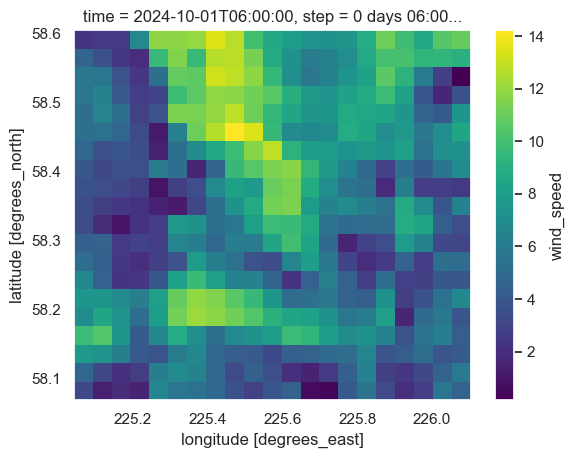

In [43]:
ds['wind_speed'][1].plot()

In [60]:
# Transformer from WGS84 (lat/lon) to UTM Zone 8N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

# # Input in (lon, lat) order for Powderpatch area
# xmin_lon, ymin_lat = -134.594876, 58.238519
# xmax_lon, ymax_lat = -134.445151, 58.308517

# This bounding box is for the general Juneau region
xmin_lon, xmax_lon = -134.964, -133.893
ymin_lat, ymax_lat = 58.077, 58.603

# Convert all corners
xmin, ymin = transformer.transform(xmin_lon, ymin_lat)
xmax, ymax = transformer.transform(xmax_lon, ymax_lat)

print(f"UTM BBox: xmin={xmin:.2f}, xmax={xmax:.2f}, ymin={ymin:.2f}, ymax={ymax:.2f}")

# ds_utm_clipped = ds_utm.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax)

UTM BBox: xmin=502123.36, xmax=564328.43, ymin=6437283.43, ymax=6496377.68


In [61]:
# check the crs of the xarray dataset
# print('crs of the gdal tif', gdal_dem.rio.crs)
print("crs of the xarray dataset:", ds_hrrr.rio.crs)
print("crs of the xarray dataset:", ds_hrrr_wind.rio.crs)
print("crs of the xarray dataset:", ds_utm.rio.crs)

crs of the xarray dataset: EPSG:4326
crs of the xarray dataset: EPSG:4326
crs of the xarray dataset: EPSG:32608


In [62]:
# # Bounding box in lat/lon
# xmin, ymin, xmax, ymax = 225.3, 58.238519, 225.8, 58.308517

# clipped = ds_hrrr_wind.rio.clip_box(minx=xmin, maxx=xmax, miny=ymin, maxy=ymax)

In [63]:
# Clip all variables spatially
ds_utm_clipped = ds_utm.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax)

# ds_hrrr_wind_clipped = ds_utm.rio.clip_box(minx=523787.03, miny=6455337.22, 
                                                #  maxx=532513.90, maxy=6463193.11)

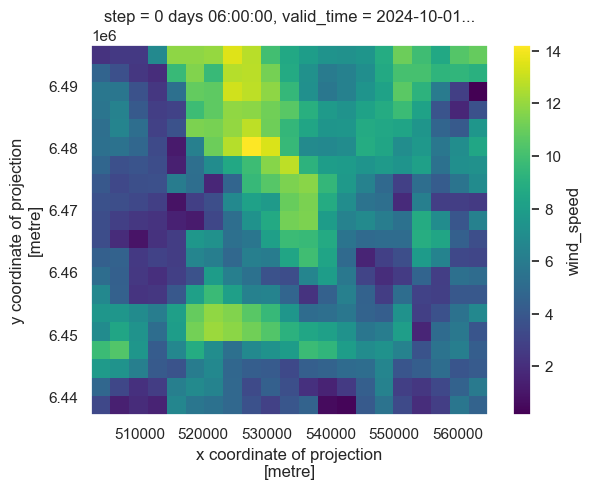

In [64]:
ds_utm_clipped['wind_speed'][1].plot()

## Now I need to allign the wind data to the DEM 

In [49]:
ds_utm_clipped.to_netcdf("/hdd/snow_hydrology/hrrrak/netcdf/ds_hrrr_wind_powderpatch_test1_UTM.nc")

In [50]:
from rasterio.enums import Resampling

In [65]:
# Load the DEM and wind dataset (assumed to already be in UTM)
dem = rioxarray.open_rasterio("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_3km_UTM_clip_powderpatch_filled_gdal.tif", masked=True)
# dem = rioxarray.open_rasterio("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_3km_UTM_clip_juneau_filled_gdal.tif", masked=True)
wind_ds = ds_utm_clipped  # your xarray Dataset with wind_speed and wind_dir variables

# Match the spatial grid to the DEM (clip, reproject, and resample)
wind_ds_aligned = wind_ds.rio.reproject_match(dem, resampling=Resampling.bilinear)

# # Save aligned layers as .asc files
# wind_ds_aligned['wind_speed'].rio.to_raster("wind_speed_aligned.asc")
# wind_ds_aligned['wind_dir'].rio.to_raster("wind_dir_aligned.asc")

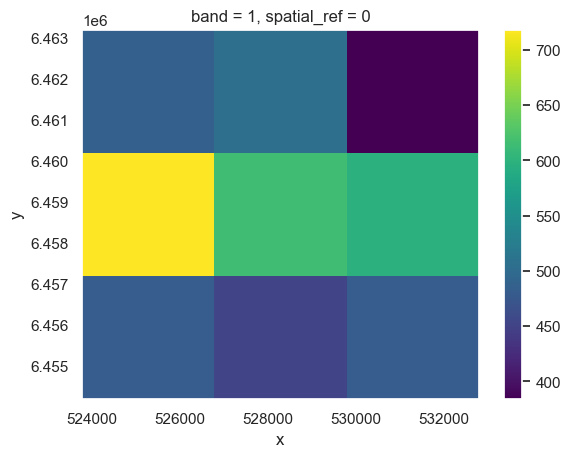

In [66]:
dem.plot()

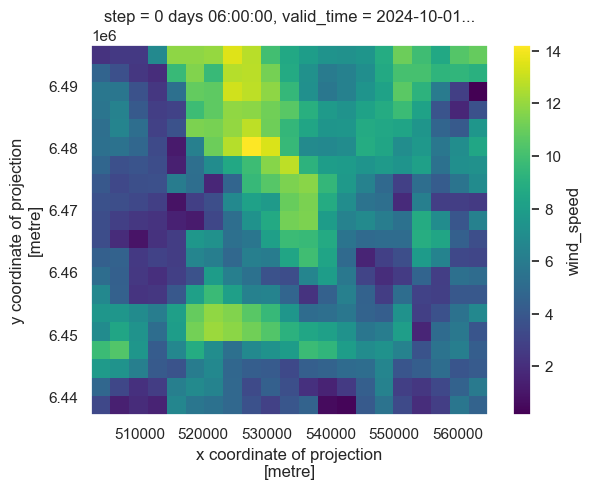

In [69]:
ds_utm_clipped['wind_speed'][1].plot()

In [53]:
# print the xllcorner and the yll corner of the dem
xllcorner = dem.rio.transform()[2]
yllcorner = dem.rio.transform()[5]
print(f"xllcorner: {xllcorner}, yllcorner: {yllcorner}")

xllcorner: 523787.02821314055, yllcorner: 6463193.107684084


In [54]:
# DEM extent
with rasterio.open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_100m_UTM_clip_powderpatch_filled_gdal.tif") as src:
    dem_bounds = src.bounds
    dem_res = src.res
    print("DEM bounds:", dem_bounds)
    print("DEM resolution:", dem_res)

# Wind grid extent from ASCII header
ncols, nrows = 3, 3
xllcorner = 523787.02821314055
yllcorner = 6463193.107684084
cellsize = 3000.0

xurcorner = xllcorner + ncols * cellsize
yurcorner = yllcorner + nrows * cellsize

print("Wind grid extent:", (xllcorner, yllcorner, xurcorner, yurcorner))


DEM bounds: BoundingBox(left=523787.02821314055, bottom=6455293.107684084, right=532587.0282131406, top=6463193.107684084)
DEM resolution: (100.0, 100.0)
Wind grid extent: (523787.02821314055, 6463193.107684084, 532787.0282131406, 6472193.107684084)


In [55]:
# dem = rioxarray.open_rasterio("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_50m_UTM_clip_powderpatch_filled_gdal.tif", masked=True)
# # print the xllcorner and the yll corner of the dem
# xllcorner = dem.rio.transform()[2]
# yllcorner = dem.rio.transform()[5]
# print(f"xllcorner: {xllcorner}, yllcorner: {yllcorner}")

In [34]:
# # -------------------
# # 1. Load DEM
# # -------------------
# dem = rioxarray.open_rasterio("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_100m_UTM_clip_powderpatch_filled_gdal.tif").squeeze()
# dem_crs = dem.rio.crs
# dem_transform = dem.rio.transform()
# dem_res = dem.rio.resolution()

# print("DEM CRS:", dem_crs)
# print("DEM resolution:", dem_res)

# # -------------------
# # 2. Select one HRRR timestep (example: first time index)
# # -------------------
# ds = ds_hrrr.isel(time=0)  # pick timestamp 0

# # Make sure HRRR has a CRS
# if not hasattr(ds, "rio"):
#     ds = ds.rio.write_crs("EPSG:3857")  # example, replace with HRRR native CRS
# print("HRRR CRS:", ds.rio.crs)

# # -------------------
# # 3. Extract U/V wind components & compute speed and direction
# # -------------------
# u = ds["u10"]  # adapt variable names if different
# v = ds["v10"]

# # Wind speed
# speed = np.sqrt(u**2 + v**2)

# # Wind direction (meteorological: from where the wind blows, clockwise from north)
# direction = (180.0 + np.degrees(np.arctan2(u, v))) % 360

# # Attach CRS
# speed = speed.rio.write_crs(ds.rio.crs)
# direction = direction.rio.write_crs(ds.rio.crs)

# # -------------------
# # 4. Reproject to DEM grid
# # -------------------
# speed_on_dem = speed.rio.reproject_match(dem)
# direction_on_dem = direction.rio.reproject_match(dem)

# # -------------------
# # 5. Export ASCII grids
# # -------------------
# def export_ascii(array, filename, nodata=-9999):
#     """Save xarray DataArray as ESRI ASCII grid"""
#     array = array.squeeze()

#     # metadata
#     ncols, nrows = array.shape[1], array.shape[0]
#     xllcorner, yllcorner = array.rio.transform()[2], array.rio.transform()[5] + nrows * dem_res[1]
#     cellsize = dem_res[0]

#     # write header
#     with open(filename, "w") as f:
#         f.write(f"ncols         {ncols}\n")
#         f.write(f"nrows         {nrows}\n")
#         f.write(f"xllcorner     {array.rio.transform()[2]}\n")
#         f.write(f"yllcorner     {array.rio.transform()[5]}\n")
#         f.write(f"cellsize      {cellsize}\n")
#         f.write(f"NODATA_value  {nodata}\n")

#         # write data rows
#         np.savetxt(f, array.values, fmt="%.3f")

# # Export both grids
# export_ascii(speed_on_dem, "wind_speed.asc")
# export_ascii(direction_on_dem, "wind_dir.asc")

# print("WindNinja ASCII files written: wind_speed.asc, wind_dir.asc")

### okay, something does look weird on the side here (with Juneau DEM, not PP), perhaps that's our problem? not sure...

come back to this 

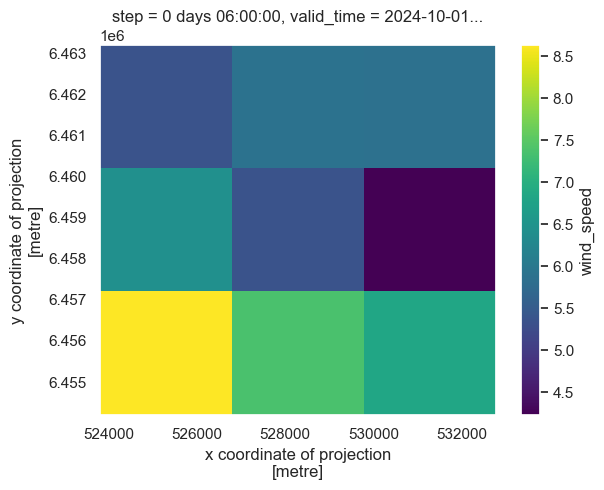

In [70]:
wind_ds_aligned['wind_speed'][1].plot()

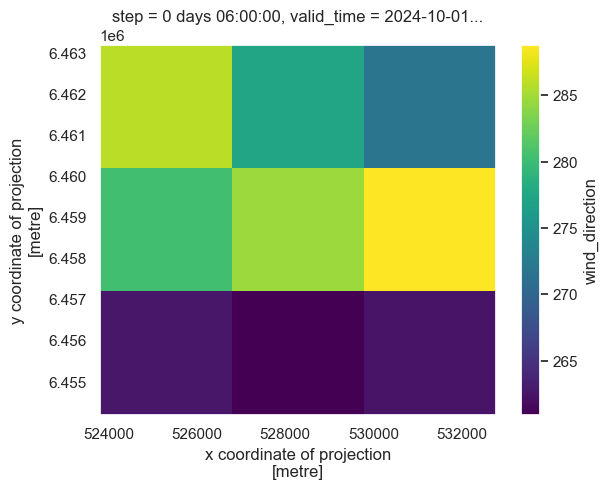

In [57]:
wind_ds_aligned['wind_direction'][1].plot()

In [47]:
# print the xllcorner and the yll corner of the dem
xllcorner = dem.rio.transform()[2]
yllcorner = dem.rio.transform()[5]
print(f"xllcorner: {xllcorner}, yllcorner: {yllcorner}")

xllcorner: 523787.02821314055, yllcorner: 6463193.107684084


In [45]:
# print the xllcorner and the yll corner of the wind_ds_aligned
xllcorner = wind_ds_aligned.rio.transform()[2]
yllcorner = wind_ds_aligned.rio.transform()[5]
print(f"xllcorner: {xllcorner}, yllcorner: {yllcorner}")

xllcorner: 523787.02821314055, yllcorner: 6463193.107684084


In [28]:
ds_utm_clipped = wind_ds_aligned.copy(deep=True)

In [29]:
# We want to create a short time series of wind speed and direction for the Powder Patch area.
# We can use the `sel` method to select a specific time range.
# For example, we can select the first 10 time steps.
ds_utm_clipped_short = ds_utm_clipped.sel(time=slice("2024-10-01", "2024-12-01"))
ds_utm_clipped_short

<xarray.Dataset> Size: 248kB
Dimensions:                  (time: 1478, x: 3, y: 3)
Coordinates:
    step                     (time) timedelta64[ns] 12kB 05:00:00 ... 05:00:00
    boundaryLayerCloudLayer  float64 8B 0.0
    valid_time               (time) datetime64[ns] 12kB 2024-10-01T05:00:00 ....
  * time                     (time) datetime64[ns] 12kB 2024-10-01T05:00:00 ....
    spatial_ref              int64 8B 0
  * x                        (x) float64 24B 5.253e+05 5.283e+05 5.313e+05
  * y                        (y) float64 24B 6.462e+06 6.459e+06 6.456e+06
Data variables:
    u10                      (time, y, x) float32 53kB -6.005 -5.907 ... -5.083
    v10                      (time, y, x) float32 53kB 0.5335 ... -0.3572
    wind_speed               (time, y, x) float32 53kB 6.085 5.936 ... 4.402 5.1
    wind_direction           (time, y, x) float32 53kB 275.9 265.4 ... 266.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

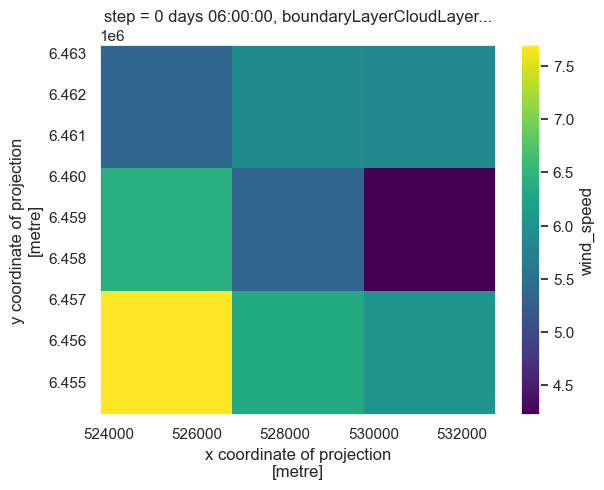

In [30]:
ds_utm_clipped_short['wind_speed'][1].plot()

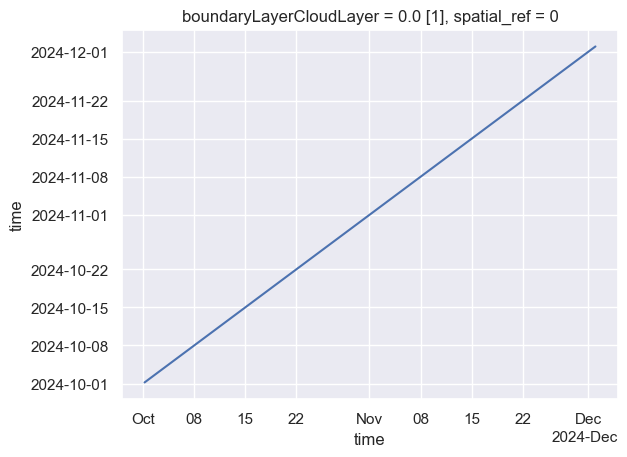

In [31]:
ds_utm_clipped_short['time'].plot()

In [32]:
# Save the short time series of wind speed and direction to a NetCDF file
ds_utm_clipped_short.to_netcdf("/hdd/snow_hydrology/hrrrak/netcdf/ds_hrrr_wind_powderpatch_test1_UTM_short_time.nc")

## Wind Ninja needs the wind speed and direction in ascii files 

In [70]:
# # now we need to save the wind speed and direction in ascii files for WindNinja
# ds_utm_clipped_short['wind_speed'].to_dataframe().to_csv("/hdd/snow_hydrology/wind_ninja/test/ds_hrrr_wind_powderpatch_test1_UTM_short_time_wind_speed.csv")
# ds_utm_clipped_short['wind_direction'].to_dataframe().to_csv("/hdd/snow_hydrology/wind_ninja/test/ds_hrrr_wind_powderpatch_test1_UTM_short_time_wind_direction.csv")

### These files are wind speed and wind direction at a given timestep (one hour)...

So hte Ascii File Format is, 

ncols         40 (4km x 4km at 100 m res, gives 40)\
nrows         40\
xllcorner     2782000\
yllcorner     1182000\
cellsize      100\
NODATA_value  -9999\
data row 1\
data row 2\
...\
data row N



In [71]:
def write_ascii_grid(filename, data, xllcorner, yllcorner, cellsize, nodata_value=-9999):
    """
    Write a 2D numpy array to ESRI ASCII format (.asc)
    
    Parameters:
    - filename: output file path
    - data: 2D numpy array
    - xllcorner, yllcorner: lower-left corner coordinates (meters)
    - cellsize: resolution (assumed square)
    - nodata_value: value to use for missing data
    """
    nrows, ncols = data.shape

    # Flip data vertically: ASCII grid is top-down
    data_flipped = np.flipud(data)

    with open(filename, 'w') as f:
        f.write(f"ncols         {ncols}\n")
        f.write(f"nrows         {nrows}\n")
        f.write(f"xllcorner     {xllcorner}\n")
        f.write(f"yllcorner     {yllcorner}\n")
        f.write(f"cellsize      {cellsize}\n")
        f.write(f"NODATA_value  {nodata_value}\n")
        
        for row in data_flipped:
            row_str = '\t'.join([f"{val:.2f}" if np.isfinite(val) else str(nodata_value) for val in row])
            f.write(row_str + '\n')

In [74]:
ls

1_api_request_get_data.ipynb
1_open_hrrrak_example_file_full.ipynb
1_open_hrrrak_example_file_juneau.ipynb
2_clean_all_powderpatch_synoptic.ipynb
2_load_all_powderpatch_mesonet.ipynb
2_load_all_powderpatch_microspecialties.ipynb
2_load_all_powderpatch_synoptic.ipynb
2_load_test_data_mesonet.ipynb
3_load_douglas_island_all_stations_mesonet.ipynb
3_load_mesonet_WY2025.ipynb
4_load_test_data_hrrrak.ipynb
4_merge_test_data_hrrrak.ipynb
5_compare_all_precipitation.ipynb
5_compare_hrrrak_powderpatch.ipynb
6a_load_clip_arctic_dem.ipynb
6b_fill_and_resample_dem_gdal.ipynb
6c_prepare_wind_fields_wind_ninja.ipynb
6c_prepare_wind_fields_wind_ninja_v2_edits.ipynb
6d_create_wind_ninja_input.ipynb
7_process_different_forecasts_netcdf_WY2024.ipynb
7_process_different_forecasts_netcdf_WY2025.ipynb
8_load_netcdf_different_forecasts_WY2024.ipynb
8_load_netcdf_different_forecasts_WY2025.ipynb
9_snow17_testing.ipynb
archive_scripts/
example_notebook.ipynb
README.md


## ASSIGNING HERE

In [72]:
# get ds_utm_clipped['wind_speed'] and ds_utm_clipped['wind_direction'] as 2D numpy arrays
wind_speed = ds_utm_clipped['wind_speed'].values
wind_direction = ds_utm_clipped['wind_direction'].values

In [73]:
# Assume wind_speed and wind_direction are 2D numpy arrays
# Get grid metadata from your dataset (ds_utm)

cellsize = ds_utm.x.diff("x").mean().item()  # Assumes uniform spacing
xll = ds_utm.x.min().item()
yll = ds_utm.y.min().item()

# Commenting this line out since this was all the values, but really we want to do this for each time step
write_ascii_grid("/hdd/snow_hydrology/wind_ninja/test3/wind_speed_test.asc", wind_speed[1], xll, yll, cellsize)
write_ascii_grid("/hdd/snow_hydrology/wind_ninja/test3/wind_direction_test.asc", wind_direction[1], xll, yll, cellsize)


## AND CREATE PRJ FILE 

In [40]:
from pyproj import CRS

In [41]:
# ds = xr.open_dataset("your_file.tif", engine="rasterio")
ds = ds_utm_clipped.copy()

# Get the CRS from the dataset
crs = ds.rio.crs  # if using rioxarray
# If rioxarray not available, use rasterio directly:
# with rasterio.open("your_file.tif") as src:
#     crs = src.crs

if crs is None:
    raise ValueError("No CRS found in dataset. Check that the GeoTIFF has projection info.")

# Convert CRS to WKT (ESRI version so ArcGIS/QGIS recognizes it in .prj files)
wkt = CRS.from_user_input(crs).to_wkt("WKT1_ESRI")

# Write to a .prj file
with open("/hdd/snow_hydrology/wind_ninja/test3/test_proj.prj", "w") as f:
    f.write(wkt)

print("PRJ file created successfully.")

PRJ file created successfully.


## BUT the wnss and wnds files are at a given time step (one hour) 

In [85]:
def write_ascii_grid(filename, data, xllcorner, yllcorner, cellsize, nodata_val=-9999):
    nrows, ncols = data.shape
    with open(filename, 'w') as f:
        f.write(f"ncols         {ncols}\n")
        f.write(f"nrows         {nrows}\n")
        f.write(f"xllcorner     {xllcorner}\n")
        f.write(f"yllcorner     {yllcorner}\n")
        f.write(f"cellsize      {cellsize}\n")
        f.write(f"NODATA_value  {nodata_val}\n")
        for row in data:
            f.write("\t".join([f"{val:.1f}" if not np.isnan(val) else str(nodata_val) for val in row]))
            f.write("\n")

Then loop through time steps and write to file, 

In [ ]:
# Get cellsize and lower-left corner
cellsize = float(ds_utm_clipped_short.x.diff("x").mean())
xll = float(ds_utm_clipped_short.x.min())
yll = float(ds_utm_clipped_short.y.min())

# Loop through time steps
for i in range(ds_utm_clipped_short.dims["time"]):
    wind_speed_2d = ds_utm_clipped_short['wind_speed'].isel(time=i).values
    wind_direction_2d = ds_utm_clipped_short['wind_direction'].isel(time=i).values

    # Replace NaNs if needed
    wind_speed_2d = np.nan_to_num(wind_speed_2d, nan=-9999)
    wind_direction_2d = np.nan_to_num(wind_direction_2d, nan=-9999)

    # Write to file with padded index
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test1/wind_speed_{i:04d}.asc", wind_speed_2d, xll, yll, cellsize)
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test1/wind_dir_{i:04d}.asc", wind_direction_2d, xll, yll, cellsize)


/tmp/ipykernel_1249164/656482094.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds_utm_clipped_short.dims["time"]):


Loop with the timestamp in the name, 

In [ ]:
for i in range(ds_utm.dims["time"]):
    # Extract timestamp as a string, e.g., '2025-07-30T00-00'
    timestamp = str(ds_utm.time[i].values)
    timestamp_clean = timestamp.replace(":", "-").replace("T", "_").split(".")[0]

    wind_speed_2d = ds_utm['wind_speed'].isel(time=i).values
    wind_direction_2d = ds_utm['wind_direction'].isel(time=i).values

    # Replace NaNs
    wind_speed_2d = np.nan_to_num(wind_speed_2d, nan=-9999)
    wind_direction_2d = np.nan_to_num(wind_direction_2d, nan=-9999)

    # Write to files with timestamp in the filename
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test1/wind_speed_{timestamp_clean}.asc", wind_speed_2d, xll, yll, cellsize)
    write_ascii_grid(f"/hdd/snow_hydrology/wind_ninja/test1/wind_dir_{timestamp_clean}.asc", wind_direction_2d, xll, yll, cellsize)

/tmp/ipykernel_1249164/2212066210.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds_utm.dims["time"]):


In [37]:
# now open 1 example file and see if the file structure looks right 
example_wind_speed = "/hdd/snow_hydrology/wind_ninja/test1/wind_speed_0000.asc"
with open(example_wind_speed, 'r') as f:
    asc_content = f.readlines()

In [38]:
asc_content

['ncols         4\n',
 'nrows         3\n',
 'xllcorner     524669.000980743\n',
 'yllcorner     6456453.557460933\n',
 'cellsize      2969.4091761768796\n',
 'NODATA_value  -9999\n',
 '5.6\t6.3\t5.8\t9.7\n',
 '7.7\t5.5\t3.8\t3.4\n',
 '9.7\t7.2\t7.6\t5.8\n']

In [39]:
import zipfile
import os

### Full script including zipping files, 

In [ ]:
# --- function to write an ASCII grid ---
def write_ascii_grid(filename, array, xllcorner, yllcorner, cellsize, nodata_value=-9999):
    nrows, ncols = array.shape
    with open(filename, 'w') as f:
        f.write(f"ncols\t{ncols}\n")
        f.write(f"nrows\t{nrows}\n")
        f.write(f"xllcorner\t{xllcorner}\n")
        f.write(f"yllcorner\t{yllcorner}\n")
        f.write(f"cellsize\t{cellsize}\n")
        f.write(f"NODATA_value\t{nodata_value}\n")
        for row in array:
            row_str = '\t'.join(f"{val:.2f}" if val != nodata_value else f"{int(nodata_value)}" for val in row)
            f.write(row_str + '\n')

# --- write all timesteps to .asc files ---
asc_files = []

for i in range(ds_utm.dims["time"]):
    timestamp = str(ds_utm.time[i].values)
    timestamp_clean = timestamp.replace(":", "-").replace("T", "_").split(".")[0]

    wind_speed_2d = ds_utm['wind_speed'].isel(time=i).values
    wind_direction_2d = ds_utm['wind_direction'].isel(time=i).values

    wind_speed_2d = np.nan_to_num(wind_speed_2d, nan=-9999)
    wind_direction_2d = np.nan_to_num(wind_direction_2d, nan=-9999)

    fname_speed = f"/hdd/snow_hydrology/wind_ninja/test1/wind_speed_{timestamp_clean}.asc"
    fname_dir = f"/hdd/snow_hydrology/wind_ninja/test1/wind_dir_{timestamp_clean}.asc"

    write_ascii_grid(fname_speed, wind_speed_2d, xll, yll, cellsize)
    write_ascii_grid(fname_dir, wind_direction_2d, xll, yll, cellsize)

    asc_files.extend([fname_speed, fname_dir])

# --- zip the results ---
zip_filename = "/hdd/snow_hydrology/wind_ninja/test1/wind_ascii_files.zip"
with zipfile.ZipFile(zip_filename, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file in asc_files:
        zipf.write(file)
        os.remove(file)  # optional: remove original after adding to zip

print(f"Zipped {len(asc_files)} files to {zip_filename}")

/tmp/ipykernel_1249164/1754895764.py:18: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(ds_utm.dims["time"]):


Zipped 9444 files to /hdd/snow_hydrology/wind_ninja/test1/wind_ascii_files.zip
